![Exercise 5.1](img/exercise5.1.png)

In [2]:
import numpy as np

def gini_impurity(y):
    """Compute Gini impurity for a set of labels."""
    unique_classes, class_counts = np.unique(y, return_counts=True)
    probabilities = class_counts / class_counts.sum()
    gini = 1 - np.sum(probabilities ** 2)
    return gini

def weighted_gini(left_y, right_y):
    """Compute weighted Gini impurity for a split."""
    total_samples = len(left_y) + len(right_y)
    weight_left = len(left_y) / total_samples
    weight_right = len(right_y) / total_samples
    return weight_left * gini_impurity(left_y) + weight_right * gini_impurity(right_y)

# Example dataset
X = np.array([
    [3, 1],
    [3, 2],
    [3, 1],
    [4, 2],
    [5, 1]
])
y = np.array([0, 1, 1, 1, 0])  # Binary labels 0=A, 1=B

# Checking splits based on Feature 1
thresholds = np.unique(X[:, 0])
best_gini_x1 = 1
best_split_x1 = None

for t in thresholds:
    left_y = y[X[:, 0] <= t]
    right_y = y[X[:, 0] > t]
    gini = weighted_gini(left_y, right_y)
    
    if gini < best_gini_x1:
        best_gini_x1 = gini
        best_split_x1 = t

print(f"Best Split at Feature 1 Threshold: {best_split_x1}, Gini: {best_gini_x1:.3f}")

# Checking splits based on Feature 2
thresholds = np.unique(X[:, 1])
best_gini_x2 = 1
best_split_x2 = None

for t in thresholds:
    left_y = y[X[:, 1] <= t]
    right_y = y[X[:, 1] > t]
    gini = weighted_gini(left_y, right_y)
    
    if gini < best_gini_x2:
        best_gini_x2 = gini
        best_split_x2 = t

print(f"Best Split at Feature 2 Threshold: {best_split_x2}, Gini: {best_gini_x2:.3f}")


Best Split at Feature 1 Threshold: 4, Gini: 0.300
Best Split at Feature 2 Threshold: 1, Gini: 0.267


Gini Impurity of the dataset: 0.480


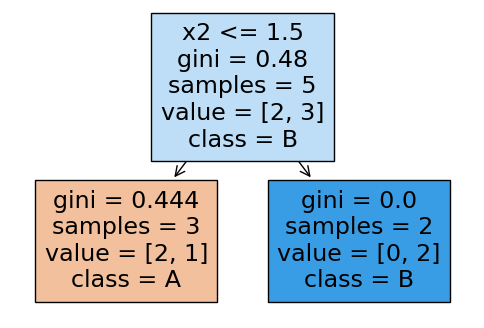

In [3]:
#Chat-GPT solution
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Define the dataset from the exercise
data = pd.DataFrame({
    "x1": [3, 3, 3, 4, 5],
    "x2": [1, 2, 1, 2, 1],
    "y":  ["A", "B", "B", "B", "A"]
})

# Function to compute Gini Impurity
def gini_impurity(y):
    """Computes the Gini impurity of a dataset"""
    unique_classes, class_counts = np.unique(y, return_counts=True)
    probabilities = class_counts / class_counts.sum()
    gini = 1 - np.sum(probabilities ** 2)
    return gini

# Compute Gini impurity for the whole dataset
gini_dataset = gini_impurity(data["y"])
print(f"Gini Impurity of the dataset: {gini_dataset:.3f}")

# Train Decision Tree with max_depth=1
X = data[["x1", "x2"]]
y = data["y"]

# Encode target labels numerically
y_encoded = y.astype('category').cat.codes  # Convert A/B to 0/1

# Train the model
clf = DecisionTreeClassifier(max_depth=1, criterion="gini", random_state=42)
clf.fit(X, y_encoded)

# Plot the Decision Tree
plt.figure(figsize=(6, 4))
plot_tree(clf, feature_names=["x1", "x2"], class_names=["A", "B"], filled=True)
plt.show()